# **Partie** **I** : **Travail** **demandé**

In [17]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
np.random.seed(42)
tf.random.set_seed(42)

Q1) Chargement + index temporel + sélection variables

In [4]:
#Chargement de données
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = tf.keras.utils.get_file("jena_climate_2009_2016.csv.zip", origin=url, extract=False)

extract_dir = os.path.dirname(zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_dir)

csv_path = os.path.join(extract_dir, "jena_climate_2009_2016.csv")
df = pd.read_csv(csv_path)
print("Taille initiale :", df.shape)
print(df.head())

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Taille initiale : (420551, 15)
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   r

In [5]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format="%d.%m.%Y %H:%M:%S")
df.set_index('Date Time', inplace=True)

print(df.dtypes)

p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object


In [6]:
feature_cols = ['T (degC)', 'rh (%)', 'p (mbar)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
data = df[feature_cols].copy()

print("taille ds  globale",df.shape)
print("taille de sous ds", data.shape)

taille ds  globale (420551, 14)
taille de sous ds (420551, 6)


Q2) Rééchantillonnage + X / Y

In [7]:
data_hourly = data.resample("1H").mean()

print(data_hourly.head())
feature_cols = data_hourly.columns.tolist()

target_cols = [
    "T (degC)",
    "rh (%)",
    "p (mbar)"
]

X = data_hourly[feature_cols]
y = data_hourly[target_cols]

print("Shape X :", X.shape)
print("Shape y :", y.shape)

                     T (degC)     rh (%)    p (mbar)  wv (m/s)  max. wv (m/s)  \
Date Time                                                                       
2009-01-01 00:00:00 -8.304000  93.780000  996.528000  0.520000       1.002000   
2009-01-01 01:00:00 -8.065000  93.933333  996.525000  0.316667       0.711667   
2009-01-01 02:00:00 -8.763333  93.533333  996.745000  0.248333       0.606667   
2009-01-01 03:00:00 -8.896667  93.200000  996.986667  0.176667       0.606667   
2009-01-01 04:00:00 -9.348333  92.383333  997.158333  0.290000       0.670000   

                       wd (deg)  
Date Time                        
2009-01-01 00:00:00  174.460000  
2009-01-01 01:00:00  172.416667  
2009-01-01 02:00:00  196.816667  
2009-01-01 03:00:00  157.083333  
2009-01-01 04:00:00  150.093333  
Shape X : (70129, 6)
Shape y : (70129, 3)


/tmp/ipykernel_4252/1857507361.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_hourly = data.resample("1H").mean()


Q3) Gestion des valeurs manquantes

In [8]:
print(data_hourly.isnull().sum())

T (degC)         88
rh (%)           88
p (mbar)         88
wv (m/s)         88
max. wv (m/s)    88
wd (deg)         88
dtype: int64


In [9]:
data_hourly = data_hourly.interpolate(method="time").dropna()

X = data_hourly[feature_cols]
y = data_hourly[target_cols]

print("Taille après interpolation :", data_hourly.shape)
print(data_hourly.isnull().sum())

Taille après interpolation : (70129, 6)
T (degC)         0
rh (%)           0
p (mbar)         0
wv (m/s)         0
max. wv (m/s)    0
wd (deg)         0
dtype: int64


Q4) Découpage train / validation / test

In [10]:
n = len(X)

train_size = int(n * 0.70)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

X_train_df = X.iloc[:train_size]
X_val_df = X.iloc[train_size:train_size + val_size]
X_test_df = X.iloc[train_size + val_size:]

y_train_df = y.iloc[:train_size]
y_val_df = y.iloc[train_size:train_size + val_size]
y_test_df = y.iloc[train_size + val_size:]

print(X_train_df.shape, X_val_df.shape, X_test_df.shape)
print(y_train_df.shape, y_val_df.shape, y_test_df.shape)

(49090, 6) (10519, 6) (10520, 6)
(49090, 3) (10519, 3) (10520, 3)


Q5) Normalisation

In [11]:

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_df)
X_val_scaled = scaler_X.transform(X_val_df)
X_test_scaled = scaler_X.transform(X_test_df)

y_train_scaled = scaler_y.fit_transform(y_train_df)
y_val_scaled = scaler_y.transform(y_val_df)
y_test_scaled = scaler_y.transform(y_test_df)

print(X_train_scaled.shape, y_train_scaled.shape)

(49090, 6) (49090, 3)


Q6) Création des séquences

In [14]:
lookback = 72
horizon = 12

def create_sequences(X, y, lookback, horizon):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback - horizon + 1):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i+lookback:i+lookback+horizon])
    return np.array(X_seq), np.array(y_seq)

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, lookback, horizon)
X_val, y_val = create_sequences(X_val_scaled, y_val_scaled, lookback, horizon)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, lookback, horizon)


Q7) Dimensions

In [15]:
print("Shape X_train :", X_train.shape)
print("Shape y_train :", y_train.shape)
print("Shape X_val:", X_val. shape)
print("Shape y_val:", y_val.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_test :", y_test.shape)

Shape X_train : (49007, 72, 6)
Shape y_train : (49007, 12, 3)
Shape X_val: (10436, 72, 6)
Shape y_val: (10436, 12, 3)
Shape X_test : (10437, 72, 6)
Shape y_test : (10437, 12, 3)


**Interprétation :**

**X_train** a la forme (n_samples, 72, 6) :
 - 72 représente le lookback
 - 6 représente le nombre de variables d’entré (features)

**y_train** a la forme (n_samples, 12, 3) :
 - 12 représente l’horizon de prédiction
 - 3 représente le nombre de variables cibles (target)

Q8) Flatten sortie

In [16]:
n_targets = y_train.shape[2]

y_train_flat = y_train.reshape((y_train.shape[0], horizon * n_targets))
y_val_flat = y_val.reshape((y_val.shape[0], horizon * n_targets))
y_test_flat = y_test.reshape((y_test.shape[0], horizon * n_targets))

print("Shape y_train_flat :", y_train_flat.shape)
print("Shape y_val_flat :", y_val_flat.shape)
print("Shape y_test_flat :", y_test_flat.shape)

Shape y_train_flat : (49007, 36)
Shape y_val_flat : (10436, 36)
Shape y_test_flat : (10437, 36)


Q9) LSTM + BiLSTM

In [18]:

def build_lstm():
    model = Sequential([
        LSTM(64, input_shape=(lookback, X_train.shape[2])),
        Dense(horizon * n_targets)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_bilstm():
    model = Sequential([
        Bidirectional(LSTM(64), input_shape=(lookback, X_train.shape[2])),
        Dense(horizon * n_targets)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

lstm_model = build_lstm()
bilstm_model = build_bilstm()

print("nRésumé modèle LSTM :")
lstm_model.summary()
print("nRésumé modèle BiLSTM :")
bilstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


nRésumé modèle LSTM :


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,996 (160.14 KB)

 Trainable params: 40,996 (160.14 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_lstm = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train, y_train_flat,
    validation_data=(X_val, y_val_flat),
    epochs=30,
    batch_size=64,
    callbacks=[early_lstm],
    verbose=1
)

Epoch 1/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0192 - val_loss: 0.0064
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0053 - val_loss: 0.0057
Epoch 3/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0048 - val_loss: 0.0052
Epoch 4/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0045 - val_loss: 0.0050
Epoch 5/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0043 - val_loss: 0.0048
Epoch 6/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0042 - val_loss: 0.0048
Epoch 7/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0041 - val_loss: 0.0048
Epoch 8/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0040 - val_loss: 0.0048
Epoch 9/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0040 - val_loss: 0.0046
Epoch 10/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0039 - val_loss: 0.0046
Epoch 11/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0039 - val_loss: 0.0045
Epoch 12/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/ste

In [20]:
early_bilstm = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

history_bilstm = bilstm_model.fit(
    X_train, y_train_flat,
    validation_data=(X_val, y_val_flat),
    epochs=30,
    batch_size=64,
    callbacks=[early_bilstm],
    verbose=1
)

Epoch 1/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0159 - val_loss: 0.0061
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 3/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0047 - val_loss: 0.0049
Epoch 4/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0044 - val_loss: 0.0047
Epoch 5/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 6/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 7/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0041 - val_loss: 0.0045
Epoch 8/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0040 - val_loss: 0.0045
Epoch 9/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0040 - val_loss: 0.0044
Epoch 10/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0039 - val_loss: 0.0044
Epoch 11/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0039 - val_loss: 0.0044
Epoch 12/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 

Q10) Courbes

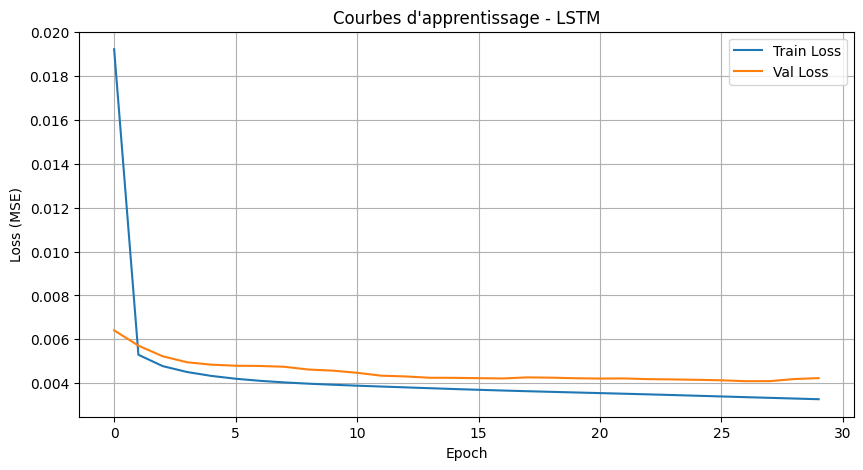

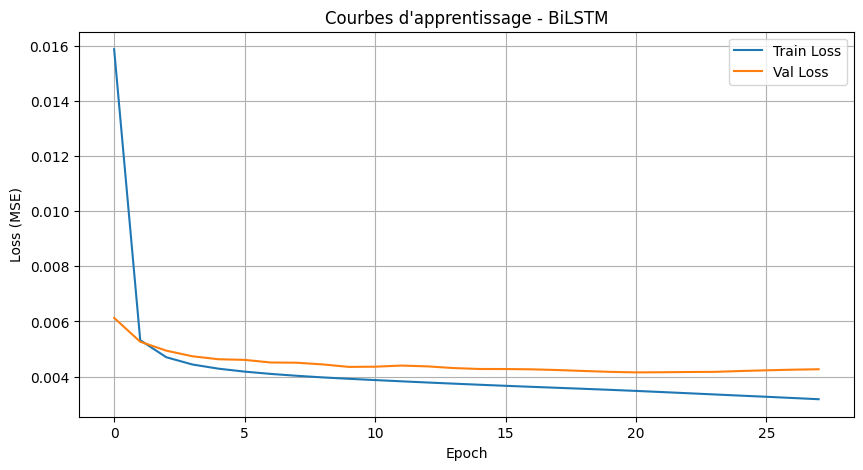

In [21]:
def plot_history(history, title):
  plt.figure(figsize=(10, 5))
  plt.plot(history.history["loss"], label="Train Loss")
  plt.plot(history.history["val_loss"], label="Val Loss")
  plt.title(title)
  plt.xlabel("Epoch")
  plt.ylabel("Loss (MSE)")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_history(history_lstm, "Courbes d'apprentissage - LSTM")
plot_history(history_bilstm, "Courbes d'apprentissage - BiLSTM")

**Interprétation :**

Pour les deux modèles LSTM et BiLSTM, on observe que le train_loss et le val_loss diminuent rapidement au début, ce qui montre que le modele apprend efficacement les relations dans les données. Ensuite, les courbes se stabilisent progressivement, indiquant que le modèle converge. La val_loss reste légèrement au dessus de la train_loss, ce qui est normal et montre qu’il n’y a pas de surapprentissage important. Globalement, les deux modèles ont un comportement similaire, avec une convergence stable et correcte.

Q11) Prédiction

In [25]:
y_pred_lstm = lstm_model.predict(X_test)
y_pred_bilstm = bilstm_model.predict(X_test)

y_pred_lstm = y_pred_lstm.reshape((-1, horizon, n_targets))
y_pred_bilstm = y_pred_bilstm.reshape((-1, horizon, n_targets))

print("pred_lstm shape : ", y_pred_lstm.shape)
print("pred_bilstm shape :", y_pred_bilstm.shape)
print("y_test shape : ", y_test.shape)

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
pred_lstm shape :  (10437, 12, 3)
pred_bilstm shape : (10437, 12, 3)
y_test shape :  (10437, 12, 3)


Q12) Inverse scaling

In [26]:
def inverse(y, scaler):
    s, h, t = y.shape
    y2d = y.reshape(s*h, t)
    y_inv = scaler.inverse_transform(y2d)
    return y_inv.reshape(s, h, t)

y_test_inv = inverse(y_test, scaler_y)
y_pred_lstm_inv = inverse(y_pred_lstm, scaler_y)
y_pred_bilstm_inv = inverse(y_pred_bilstm, scaler_y)

Q13) Évaluation

In [29]:
def evaluate_multivariate_multistep(y_true, y_pred, model_name, target_cols):
    results = []

    for h in range(y_true.shape[1]):  # horizon
        for j in range(y_true.shape[2]):  # variables

            true_hj = y_true[:, h, j]
            pred_hj = y_pred[:, h, j]

            mae = mean_absolute_error(true_hj, pred_hj)
            rmse = np.sqrt(mean_squared_error(true_hj, pred_hj))
            r2 = r2_score(true_hj, pred_hj)

            results.append({
                "Model": model_name,
                "Horizon": h + 1,
                "Variable": target_cols[j],
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            })

    return pd.DataFrame(results)


df_lstm_scores = evaluate_multivariate_multistep(y_test_inv, y_pred_lstm_inv, "LSTM", target_cols)
df_bilstm_scores = evaluate_multivariate_multistep(y_test_inv, y_pred_bilstm_inv, "BiLSTM", target_cols)
df_scores = pd.concat([df_lstm_scores, df_bilstm_scores], axis=0)

print(df_scores.head(15))

   Model  Horizon  Variable       MAE      RMSE        R2
0   LSTM        1  T (degC)  0.488167  0.650239  0.993031
1   LSTM        1    rh (%)  2.316793  3.163507  0.958199
2   LSTM        1  p (mbar)  0.363338  0.466285  0.997217
3   LSTM        2  T (degC)  0.751126  1.006617  0.983300
4   LSTM        2    rh (%)  3.557018  4.907555  0.899421
5   LSTM        2  p (mbar)  0.526314  0.674599  0.994175
6   LSTM        3  T (degC)  0.984976  1.311056  0.971672
7   LSTM        3    rh (%)  4.550507  6.196119  0.839696
8   LSTM        3  p (mbar)  0.682197  0.887831  0.989911
9   LSTM        4  T (degC)  1.181536  1.554480  0.960179
10  LSTM        4    rh (%)  5.241750  7.080433  0.790688
11  LSTM        4  p (mbar)  0.848607  1.112116  0.984172
12  LSTM        5  T (degC)  1.346727  1.750828  0.949490
13  LSTM        5    rh (%)  5.832966  7.782406  0.747124
14  LSTM        5  p (mbar)  1.028758  1.360521  0.976314


Q14) Visualisation des Métriques par horizon

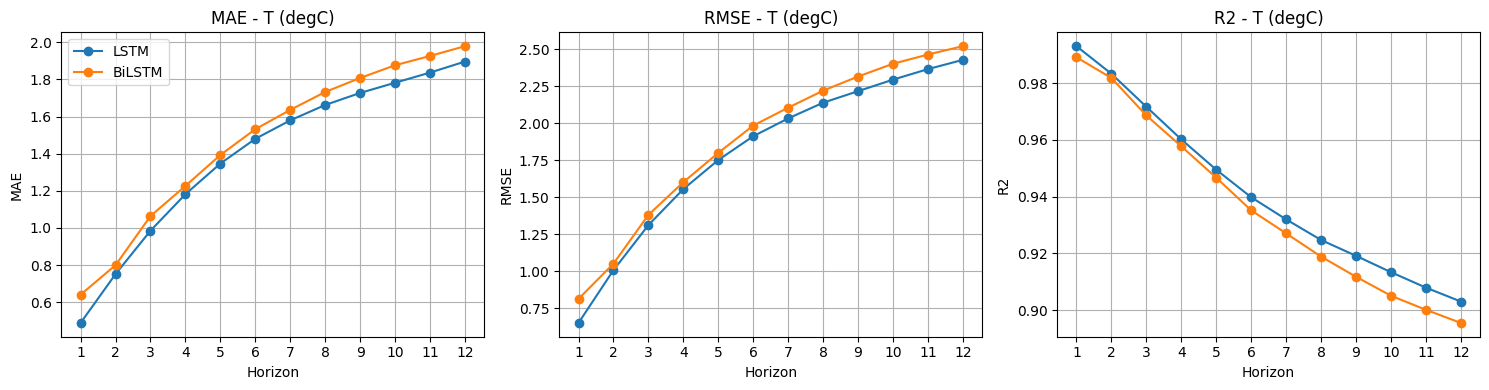

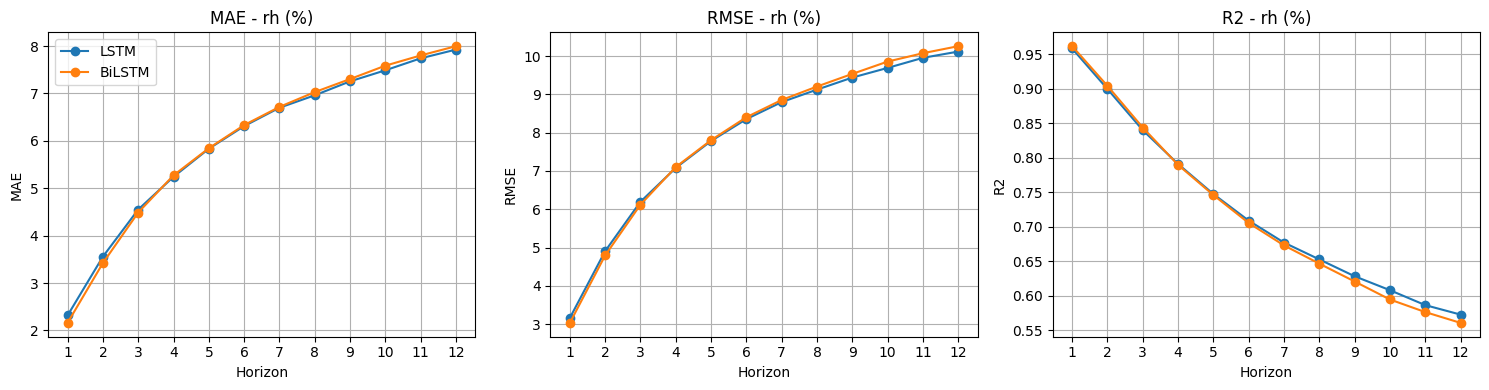

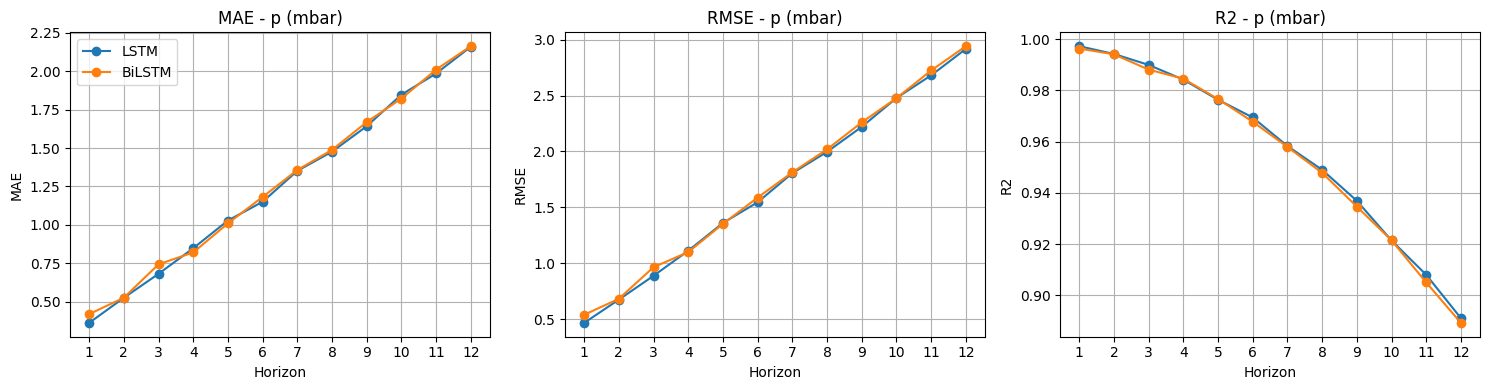

In [31]:
def plot_all_metrics(df_scores, target_cols):
    metrics = ["MAE", "RMSE", "R2"]

    for var in target_cols:
        plt.figure(figsize=(15, 4))

        for i, metric in enumerate(metrics):
            plt.subplot(1, 3, i + 1)

            for model_name in df_scores["Model"].unique():
                sub_df = df_scores[
                    (df_scores["Model"] == model_name) &
                    (df_scores["Variable"] == var)
                ]
                plt.plot(sub_df["Horizon"], sub_df[metric],
                         marker="o", label=model_name)

            plt.title(f"{metric} - {var}")
            plt.xlabel("Horizon")
            plt.ylabel(metric)
            plt.xticks(range(1, horizon + 1))
            plt.grid(True)

            if i == 0:
                plt.legend()

        plt.tight_layout()
        plt.show()

plot_all_metrics(df_scores, target_cols)

**Interprétation :**

Les courbes montrent que, pour les trois variables, MAE et RMSE augmentent avec l’horizon (ex : pour la température, MAE passe d’environ 0.5 → 1.9, RMSE de 0.7 → 2.5), tandis que R² diminue (de ≈0.99 → 0.90). Cela confirme que la prédiction devient plus difficile à long terme.

En comparant les modèles, LSTM et BiLSTM sont très proches, mais le LSTM est légèrement meilleur sur la température et la pression (erreurs un peu plus faibles). Pour l’humidité, les performances sont presque identiques (MAE ≈ 2 → 8, R² ≈ 0.95 → 0.56).

Globalement, la pression est la plus difficile à prédire (baisse rapide du R² jusqu’à ≈0.89), alors que la température reste mieux modélisé. Le BiLSTM n’apporte pas de gain significatif, donc le LSTM reste plus stable dans ce cas.

Q15) Exemple réel vs prédit

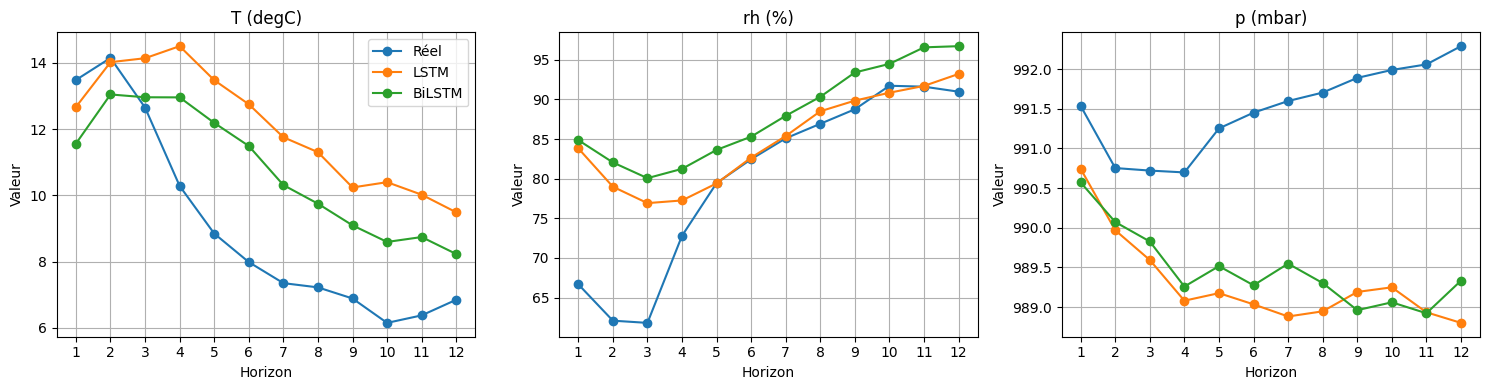

In [35]:
sample_idx = 20

def plot_forecast_comparison(y_true, y_pred_lstm, y_pred_bilstm, target_cols, sample_idx):
    horizons = np.arange(1, y_true.shape[1] + 1)

    plt.figure(figsize=(15, 4))

    for j, var_name in enumerate(target_cols):
        plt.subplot(1, 3, j + 1)

        plt.plot(horizons, y_true[sample_idx, :, j],marker="o", label="Réel")
        plt.plot(horizons, y_pred_lstm[sample_idx, :, j], marker="o", label="LSTM")
        plt.plot(horizons, y_pred_bilstm[sample_idx, :, j],marker="o", label="BiLSTM")

        plt.title(f"{var_name}")
        plt.xlabel("Horizon")
        plt.ylabel("Valeur")
        plt.xticks(horizons)
        plt.grid(True)

        if j == 0:
            plt.legend()

    plt.tight_layout()
    plt.show()

plot_forecast_comparison(
    y_test_inv,
    y_pred_lstm_inv,
    y_pred_bilstm_inv,
    target_cols,
    sample_idx
)

**Commentaire :**

Pour la **température**, les modèles capturent la tendance décroissante mais surestiment les valeurs (ex : réel ≈ 6–7 alors que LSTM ≈ 9–10 et BiLSTM ≈ 8–9 à la fin). Le BiLSTM est légèrement plus proche du réel.

Pour **l’humidité**, les prédictions sont plus proches de la réalité, surtout à partir de t+5. Cependant, on observe un décalage initial (réel ≈ 62 vs prédictions ≈ 77–80), puis les modèles convergent vers les valeurs réelles. Le BiLSTM a tendance à surestimer légèrement.

Pour la **pression**, les deux modèles suivent la direction globale mais présentent un biais constant vers le bas (réel ≈ 991–992 contre ≈ 989–990 prédit). Les variations fines ne sont pas bien capturées.

Q16) Horizon fixe

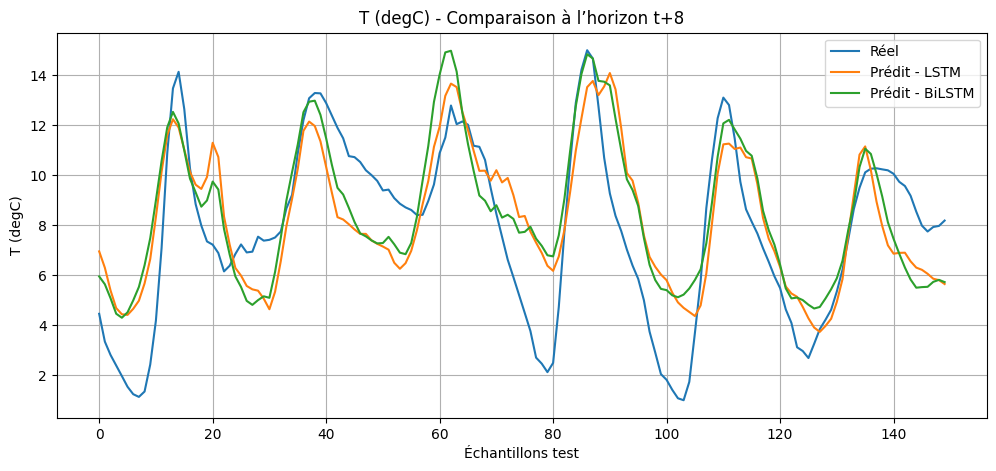

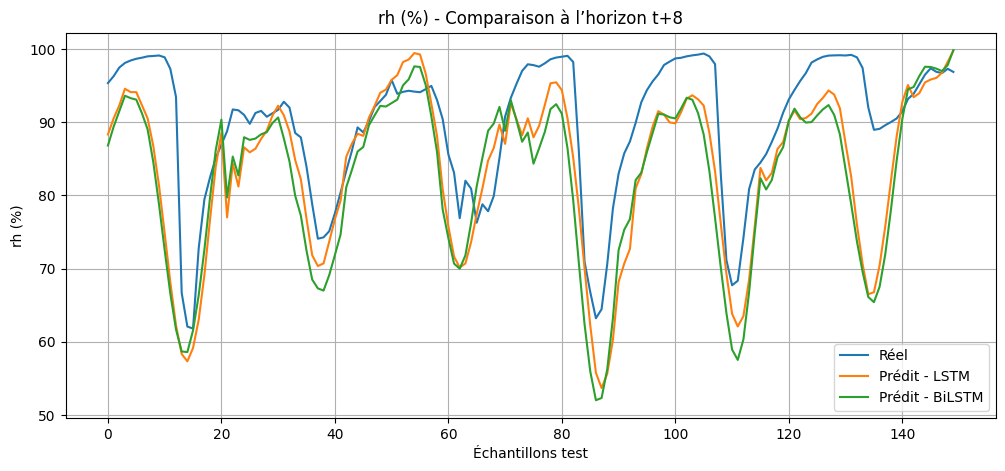

In [39]:
def plot_fixed_horizon_over_samples(y_true, y_pred_lstm, y_pred_bilstm,variable_idx, variable_name,selected_horizon, n_points=150):

    h = selected_horizon - 1

    plt.figure(figsize=(12, 5))
    plt.plot(y_true[:n_points, h, variable_idx], label="Réel")
    plt.plot(y_pred_lstm[:n_points, h, variable_idx], label="Prédit - LSTM")
    plt.plot(y_pred_bilstm[:n_points, h, variable_idx], label="Prédit - BiLSTM")

    plt.title(f"{variable_name} - Comparaison à l’horizon t+{selected_horizon}")
    plt.xlabel("Échantillons test")
    plt.ylabel(variable_name)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_fixed_horizon_over_samples(
    y_test_inv,
    y_pred_lstm_inv,
    y_pred_bilstm_inv,
    variable_idx=0,
    variable_name=target_cols[0],
    selected_horizon=8,
    n_points=150
)

plot_fixed_horizon_over_samples(
    y_test_inv,
    y_pred_lstm_inv,
    y_pred_bilstm_inv,
    variable_idx=1,
    variable_name=target_cols[1],
    selected_horizon=8,
    n_points=150
)

**Analyse :**

Pour un horizon fixé (ici t+8), les deux modèles suivent globalement la forme des séries réelles sur plusieurs échantillons, ce qui montre qu’ils capturent bien la dynamique générale.

Cependant, on observe que les prédictions sont plus lissées que les valeurs réelles : les pics et les creux sont atténués, notamment pour la température et l’humidité. Cela indique une bonne stabilité des prédictions, mais au prix d’une perte de précision sur les variations brusques.

Le BiLSTM suit légèrement mieux certaines oscillations, tandis que le LSTM reste plus régulier. Les deux modèles présentent aussi un léger décalage temporel sur certains cycles.

Q17) Conclusion

In [40]:
print("Comparaison faite avec MAE, RMSE, R2 pour chaque horizon et variable")

Comparaison faite avec MAE, RMSE, R2 pour chaque horizon et variable


À partir des résultats obtenus, le LSTM apparaît légèrement plus performant pour la température et la pression, avec des erreurs (MAE, RMSE) un peu plus faibles et une meilleure stabilité globale. Pour l’humidité, les deux modèles (LSTM et BiLSTM) donnent des performances très proches, sans différence significative.

Concernant l’architecture, le BiLSTM n’apporte pas d’amélioration notable dans ce cas. Bien qu’il puisse mieux capter certaines variations locales, son gain reste limité par rapport au LSTM simple.

Enfin, l’impact de l’horizon est clair : plus l’horizon augmente, plus les erreurs augmentent (MAE, RMSE) et plus le R² diminue. Cela montre que la qualité des prédictions se dégrade à long terme, alors que les prédictions à court horizon restent plus fiables.

# **Partie** **II** **:** **Questions** **d'analyse**

**Q1)**  On utilise deux scalers differents car les entrés X et les sorties Y n’ont pas les mêmes distributions ni les mêmes rôles. Le scaler_X normalise les données d’entré pour faciliter l’apprentissage, tandis que le scaler_y est utilisé pour les cibles afin de pouvoir ensuite revenir correctement à l’échelle réelle (inverse scaling) des prédictions.

**Q2)** La sortie réelle est une matrice 3D (n_samples, horizon, n_targets), alors que la couche Dense de Keras produit un vecteur 1D. Il faut donc aplatir la sortie en un vecteur de taille horizon × n_targets pour que le modèle puisse apprendre correctement.

**Q3)** Oui, la prédiction des valeurs moyennes est plus stable, car la moyenne lisse les fluctuations et réduit l’impact du bruit. Les valeurs extrêmes (max/min) dépendent de variations brusques et rares, ce qui les rend plus difficiles à modéliser et moins prévisibles.

**Q4)** L’évaluation doit être faite par horizon et par variable car la difficulté de prédiction varie selon le temps et la variable. Une mesure globale peut masquer des performances différentes (ex : bon à court terme mais mauvais à long terme). Cette analyse permet une évaluation plus précise et détaillée du modèle.